In [1]:
import pandas as pd
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

load_dotenv('../.env')

engine = create_engine(
    f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

print("Connected to database")

Connected to database


In [2]:
query = """
SELECT 
    rr.driver_id,
    rr.constructor_id,
    rr.grid_position,
    rr.finish_position,
    rr.points,
    rr.points_finish,
    rr.status,
    r.season,
    r.round,
    r.circuit_id,
    r.date,
    q.q1_time,
    q.q2_time,
    q.q3_time,
    w.air_temp,
    w.track_temp,
    w.rainfall,
    w.humidity
FROM race_results rr
JOIN races r ON rr.race_id = r.race_id
LEFT JOIN qualifying_results q ON q.race_id = rr.race_id AND q.driver_id = rr.driver_id
LEFT JOIN weather w ON w.race_id = rr.race_id
ORDER BY r.date, rr.finish_position
"""

df = pd.read_sql(query, engine)
print(df.shape)

(1838, 18)


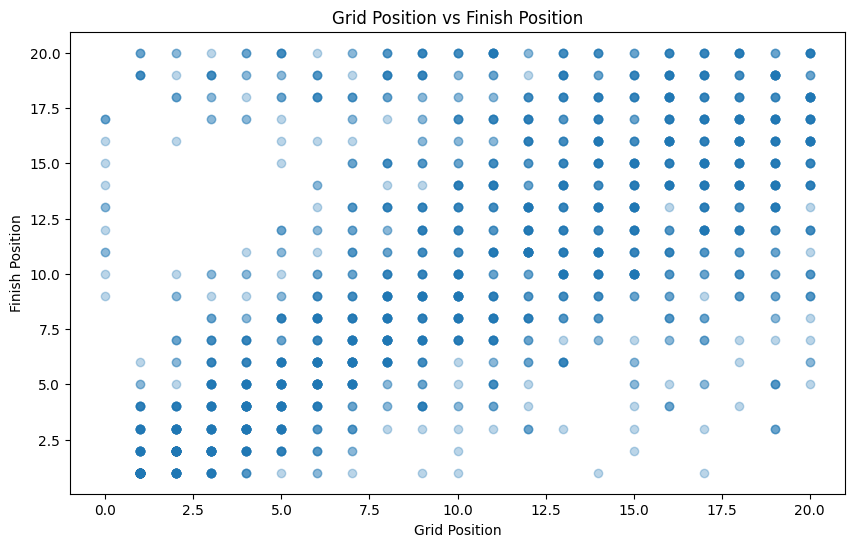

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
plt.scatter(df['grid_position'], df['finish_position'], alpha=0.3)
plt.xlabel('Grid Position')
plt.ylabel('Finish Position')
plt.title('Grid Position vs Finish Position')
plt.show()

In [4]:
print(df['points_finish'].value_counts())
print(df['points_finish'].value_counts(normalize=True))

points_finish
True     920
False    918
Name: count, dtype: int64
points_finish
True     0.500544
False    0.499456
Name: proportion, dtype: float64


In [5]:
print(df.groupby('grid_position')['points_finish'].mean().round(2))

grid_position
0.0     0.15
1.0     0.91
2.0     0.92
3.0     0.89
4.0     0.90
5.0     0.80
6.0     0.82
7.0     0.74
8.0     0.66
9.0     0.55
10.0    0.53
11.0    0.41
12.0    0.27
13.0    0.31
14.0    0.22
15.0    0.27
16.0    0.18
17.0    0.15
18.0    0.13
19.0    0.17
20.0    0.17
Name: points_finish, dtype: float64


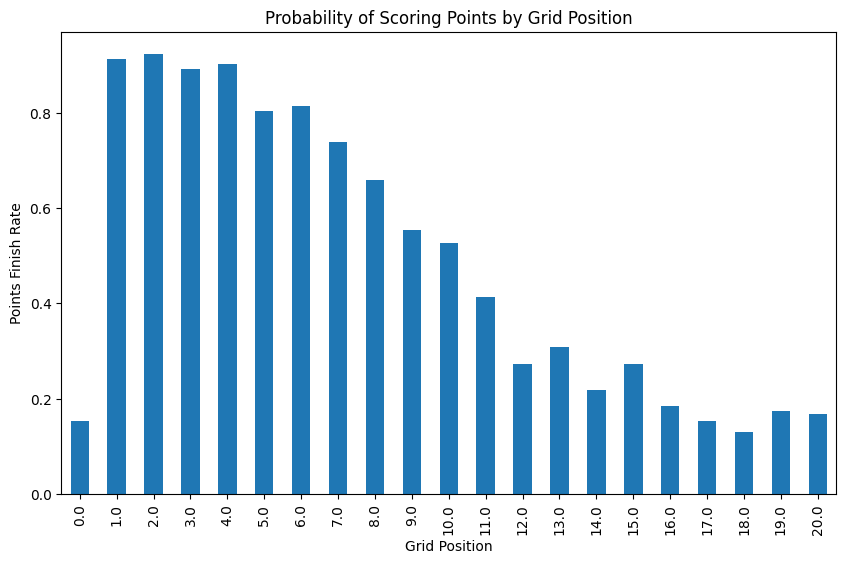

In [6]:
plt.figure(figsize=(10, 6))
df.groupby('grid_position')['points_finish'].mean().plot(kind='bar')
plt.xlabel('Grid Position')
plt.ylabel('Points Finish Rate')
plt.title('Probability of Scoring Points by Grid Position')
plt.show()

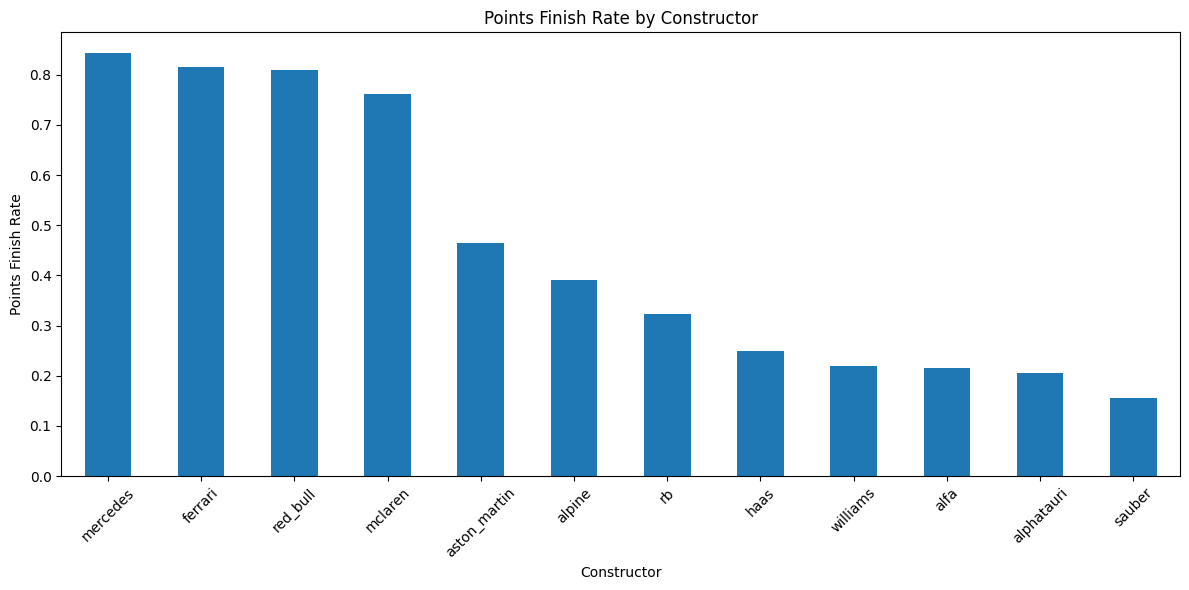

In [7]:
plt.figure(figsize=(12, 6))
df.groupby('constructor_id')['points_finish'].mean().sort_values(ascending=False).plot(kind='bar')
plt.xlabel('Constructor')
plt.ylabel('Points Finish Rate')
plt.title('Points Finish Rate by Constructor')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
# Calculate qualifying gap to pole position for each race
pole_times = df[df['grid_position'] == 1][['season', 'round', 'q3_time']].rename(columns={'q3_time': 'pole_time'})

df = df.merge(pole_times, on=['season', 'round'], how='left')
df['quali_gap_to_pole'] = df['q3_time'] - df['pole_time']

print(df[['driver_id', 'grid_position', 'q3_time', 'pole_time', 'quali_gap_to_pole']].head(20))

          driver_id  grid_position  q3_time  pole_time  quali_gap_to_pole
0           leclerc            1.0   90.558     90.558              0.000
1             sainz            3.0   90.687     90.558              0.129
2          hamilton            5.0   91.238     90.558              0.680
3           russell            9.0   92.216     90.558              1.658
4   kevin_magnussen            7.0   91.808     90.558              1.250
5            bottas            6.0   91.560     90.558              1.002
6              ocon           11.0      NaN     90.558                NaN
7           tsunoda           16.0      NaN     90.558                NaN
8            alonso            8.0   92.195     90.558              1.637
9              zhou           15.0      NaN     90.558                NaN
10  mick_schumacher           12.0      NaN     90.558                NaN
11           stroll           19.0      NaN     90.558                NaN
12            albon           14.0    

In [9]:
# Fill quali_gap_to_pole nulls with max gap in that race + 1 second penalty
df['quali_gap_to_pole'] = df.groupby(['season', 'round'])['quali_gap_to_pole'].transform(
    lambda x: x.fillna(x.max() + 1.0)
)

In [10]:
df[['driver_id', 'grid_position', 'quali_gap_to_pole']].head(20)

,driver_id,grid_position,quali_gap_to_pole
0,leclerc,1.0,0.000
1,sainz,3.0,0.129
2,hamilton,5.0,0.680
3,russell,9.0,1.658
4,kevin_magnussen,7.0,1.250
5,bottas,6.0,1.002
6,ocon,11.0,2.780
7,tsunoda,16.0,2.780
8,alonso,8.0,1.637
9,zhou,15.0,2.780


In [11]:
# Sort by driver and date first
df = df.sort_values(['driver_id', 'date']).reset_index(drop=True)

# Rolling average finish position over last 5 races
df['driver_rolling_avg_finish'] = (
    df.groupby('driver_id')['finish_position']
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)

print(df[['driver_id', 'date', 'finish_position', 'driver_rolling_avg_finish']].head(30))

   driver_id        date  finish_position  driver_rolling_avg_finish
0      albon  2022-03-20             13.0                        NaN
1      albon  2022-03-27             14.0                  13.000000
2      albon  2022-04-10             10.0                  13.500000
3      albon  2022-04-24             11.0                  12.333333
4      albon  2022-05-08              9.0                  12.000000
5      albon  2022-05-22             18.0                  11.400000
6      albon  2022-05-29             18.0                  12.400000
7      albon  2022-06-12             12.0                  13.200000
8      albon  2022-06-19             13.0                  13.600000
9      albon  2022-07-03             20.0                  14.000000
10     albon  2022-07-10             12.0                  16.200000
11     albon  2022-07-24             13.0                  15.000000
12     albon  2022-07-31             17.0                  14.000000
13     albon  2022-08-28          

In [12]:
df['constructor_rolling_avg_finish'] = (
    df.groupby('constructor_id')['finish_position']
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)

In [13]:
# Driver's career average finish, up to (not including) this race
df['driver_career_avg'] = (
    df.groupby('driver_id')['finish_position']
    .transform(lambda x: x.shift(1).expanding().mean())
)

# Driver's average finish at this specific circuit, up to (not including) this race
df['driver_circuit_avg'] = (
    df.groupby(['driver_id', 'circuit_id'])['finish_position']
    .transform(lambda x: x.shift(1).expanding().mean())
)

# Positive = overperforms at this circuit compared to career average
df['track_delta'] = df['driver_career_avg'] - df['driver_circuit_avg']

In [14]:
df[['driver_id', 'date', 'finish_position', 'driver_career_avg', 'driver_circuit_avg', 'track_delta']].head(20)

,driver_id,date,finish_position,driver_career_avg,driver_circuit_avg,track_delta
0,albon,2022-03-20,13.0,NaN,NaN,NaN
1,albon,2022-03-27,14.0,13.000000,NaN,NaN
2,albon,2022-04-10,10.0,13.500000,NaN,NaN
3,albon,2022-04-24,11.0,12.333333,NaN,NaN
4,albon,2022-05-08,9.0,12.000000,NaN,NaN
5,albon,2022-05-22,18.0,11.400000,NaN,NaN
6,albon,2022-05-29,18.0,12.500000,NaN,NaN
7,albon,2022-06-12,12.0,13.285714,NaN,NaN
8,albon,2022-06-19,13.0,13.125000,NaN,NaN
9,albon,2022-07-03,20.0,13.111111,NaN,NaN


In [15]:
df.groupby(['driver_id', 'circuit_id']).size().value_counts()

1    247
4    226
3    173
2     84
Name: count, dtype: int64

In [16]:
df['constructor_career_avg'] = (
    df.groupby('constructor_id')['finish_position']
    .transform(lambda x: x.shift(1).expanding().mean())
)

df['driver_vs_team_delta'] = df['driver_career_avg'] - df['constructor_career_avg']

In [17]:
df_circuit_sorted = df.sort_values(['circuit_id', 'date'])
df['circuit_avg_finish'] = (
    df_circuit_sorted.groupby('circuit_id')['finish_position']
    .transform(lambda x: x.shift(1).expanding().mean())
)

In [18]:
df['driver_form_delta'] = df['driver_rolling_avg_finish'] - df['driver_career_avg']

In [19]:
df['made_q2'] = df['q2_time'].notna().astype(int)
df['made_q3'] = df['q3_time'].notna().astype(int)

In [20]:
df.columns.tolist()

['driver_id',
 'constructor_id',
 'grid_position',
 'finish_position',
 'points',
 'points_finish',
 'status',
 'season',
 'round',
 'circuit_id',
 'date',
 'q1_time',
 'q2_time',
 'q3_time',
 'air_temp',
 'track_temp',
 'rainfall',
 'humidity',
 'pole_time',
 'quali_gap_to_pole',
 'driver_rolling_avg_finish',
 'constructor_rolling_avg_finish',
 'driver_career_avg',
 'driver_circuit_avg',
 'track_delta',
 'constructor_career_avg',
 'driver_vs_team_delta',
 'circuit_avg_finish',
 'driver_form_delta',
 'made_q2',
 'made_q3']

In [21]:
df.columns.tolist()

['driver_id',
 'constructor_id',
 'grid_position',
 'finish_position',
 'points',
 'points_finish',
 'status',
 'season',
 'round',
 'circuit_id',
 'date',
 'q1_time',
 'q2_time',
 'q3_time',
 'air_temp',
 'track_temp',
 'rainfall',
 'humidity',
 'pole_time',
 'quali_gap_to_pole',
 'driver_rolling_avg_finish',
 'constructor_rolling_avg_finish',
 'driver_career_avg',
 'driver_circuit_avg',
 'track_delta',
 'constructor_career_avg',
 'driver_vs_team_delta',
 'circuit_avg_finish',
 'driver_form_delta',
 'made_q2',
 'made_q3']

In [22]:
df[['grid_position', 'quali_gap_to_pole', 'made_q2', 'made_q3',
    'driver_rolling_avg_finish', 'constructor_rolling_avg_finish',
    'driver_form_delta', 'driver_career_avg', 'driver_circuit_avg',
    'track_delta', 'constructor_career_avg', 'driver_vs_team_delta',
    'air_temp', 'track_temp', 'rainfall', 'humidity']].isnull().sum()

grid_position                       2
quali_gap_to_pole                   0
made_q2                             0
made_q3                             0
driver_rolling_avg_finish          31
constructor_rolling_avg_finish     12
driver_form_delta                  31
driver_career_avg                  31
driver_circuit_avg                730
track_delta                       730
constructor_career_avg             12
driver_vs_team_delta               35
air_temp                            0
track_temp                          0
rainfall                            0
humidity                            0
dtype: int64

In [23]:
df.groupby(['circuit_id', 'date']).size()

circuit_id  date      
Austin      2022-10-23    20
            2023-10-22    20
            2024-10-20    20
            2025-10-19    20
Baku        2022-06-12    20
                          ..
Yas Island  2025-12-07    20
Zandvoort   2022-09-04    20
            2023-08-27    20
            2024-08-25    20
            2025-08-31    20
Length: 92, dtype: int64

In [24]:
df.groupby('circuit_id')['date'].nunique()

circuit_id
Austin               4
Baku                 4
Barcelona            4
Budapest             4
Imola                3
Jeddah               4
Las Vegas            3
Le Castellet         1
Lusail               3
Marina Bay           4
Melbourne            4
Mexico City          4
Miami                3
Miami Gardens        1
Monaco               4
Montréal             4
Monza                4
Sakhir               4
Shanghai             2
Silverstone          4
Spa-Francorchamps    4
Spielberg            4
Suzuka               4
São Paulo            4
Yas Island           4
Zandvoort            4
Name: date, dtype: int64

In [25]:
df[['grid_position', 'quali_gap_to_pole', 'made_q2', 'made_q3',
    'driver_rolling_avg_finish', 'constructor_rolling_avg_finish',
    'driver_form_delta', 'driver_career_avg', 'driver_circuit_avg',
    'track_delta', 'constructor_career_avg', 'driver_vs_team_delta',
    'air_temp', 'track_temp', 'rainfall', 'humidity']].isnull().sum()

grid_position                       2
quali_gap_to_pole                   0
made_q2                             0
made_q3                             0
driver_rolling_avg_finish          31
constructor_rolling_avg_finish     12
driver_form_delta                  31
driver_career_avg                  31
driver_circuit_avg                730
track_delta                       730
constructor_career_avg             12
driver_vs_team_delta               35
air_temp                            0
track_temp                          0
rainfall                            0
humidity                            0
dtype: int64

In [26]:
df['has_circuit_history'] = df['driver_circuit_avg'].notna().astype(int)

In [27]:
# Boolean flags for missing history
df['has_circuit_history'] = df['driver_circuit_avg'].notna().astype(int)

# Fill grid_position
df['grid_position'] = df['grid_position'].fillna(20)

# Fill driver/constructor career and rolling averages with overall mean
overall_mean_finish = df['finish_position'].mean()

df['driver_rolling_avg_finish'] = df['driver_rolling_avg_finish'].fillna(overall_mean_finish)
df['driver_career_avg'] = df['driver_career_avg'].fillna(overall_mean_finish)
df['constructor_rolling_avg_finish'] = df['constructor_rolling_avg_finish'].fillna(overall_mean_finish)
df['constructor_career_avg'] = df['constructor_career_avg'].fillna(overall_mean_finish)

# Fill driver_circuit_avg with their own career average (best guess without circuit history)
df['driver_circuit_avg'] = df['driver_circuit_avg'].fillna(df['driver_career_avg'])

# Fill delta features with 0 (neutral - no difference from norm)
df['track_delta'] = df['track_delta'].fillna(0)
df['driver_form_delta'] = df['driver_form_delta'].fillna(0)
df['driver_vs_team_delta'] = df['driver_vs_team_delta'].fillna(0)

print("NaNs remaining:")
print(df.isnull().sum().sum())

NaNs remaining:
1466


In [28]:
df.isnull().sum()[df.isnull().sum() > 0]

finish_position         2
q1_time                21
q2_time               476
q3_time               941
circuit_avg_finish     26
dtype: int64

In [29]:
feature_columns = [
    'grid_position', 'quali_gap_to_pole', 'made_q2', 'made_q3',
    'driver_rolling_avg_finish', 'constructor_rolling_avg_finish',
    'driver_career_avg', 'driver_circuit_avg', 'track_delta',
    'constructor_career_avg', 'driver_vs_team_delta', 'driver_form_delta',
    'has_circuit_history',
    'air_temp', 'track_temp', 'rainfall', 'humidity',
    'constructor_id', 'circuit_id'
]

model_df = df[feature_columns + ['points_finish', 'season', 'round', 'date']].copy()

print(model_df.isnull().sum().sum())
print(model_df.shape)

0
(1838, 23)


In [30]:
import numpy as np

corr_cols = feature_columns + ['points_finish']
numeric_df = model_df[corr_cols].copy()

# One-hot encode categoricals temporarily just for this correlation check
numeric_df = pd.get_dummies(numeric_df, columns=['constructor_id', 'circuit_id'], drop_first=True)

correlations = numeric_df.corr()['points_finish'].drop('points_finish').sort_values(ascending=False)
print(correlations)

made_q3                           0.566021
made_q2                           0.403039
constructor_id_mercedes           0.228036
constructor_id_ferrari            0.209909
constructor_id_red_bull           0.206284
constructor_id_mclaren            0.173655
has_circuit_history               0.098731
track_delta                       0.044798
circuit_id_Melbourne              0.002452
circuit_id_Barcelona              0.002452
track_temp                        0.000983
air_temp                          0.000243
circuit_id_Le Castellet          -0.000114
circuit_id_Miami Gardens         -0.000114
circuit_id_Shanghai              -0.000162
circuit_id_Miami                 -0.000200
circuit_id_Imola                 -0.000200
circuit_id_Las Vegas             -0.000200
circuit_id_Lusail                -0.000200
circuit_id_Yas Island            -0.000232
circuit_id_Suzuka                -0.000232
circuit_id_Silverstone           -0.000232
circuit_id_São Paulo             -0.000232
circuit_id_

In [31]:
numeric_features = [
    'grid_position', 'quali_gap_to_pole', 'made_q2', 'made_q3',
    'driver_rolling_avg_finish', 'constructor_rolling_avg_finish',
    'driver_career_avg', 'driver_circuit_avg', 'track_delta',
    'constructor_career_avg', 'driver_vs_team_delta', 'driver_form_delta',
    'has_circuit_history', 'air_temp', 'track_temp', 'rainfall', 'humidity'
]

feature_corr = model_df[numeric_features].corr()
print(feature_corr.round(2))

                                grid_position  quali_gap_to_pole  made_q2  \
grid_position                            1.00               0.40    -0.69   
quali_gap_to_pole                        0.40               1.00    -0.26   
made_q2                                 -0.69              -0.26     1.00   
made_q3                                 -0.81              -0.46     0.58   
driver_rolling_avg_finish                0.60               0.30    -0.38   
constructor_rolling_avg_finish           0.60               0.30    -0.37   
driver_career_avg                        0.60               0.28    -0.39   
driver_circuit_avg                       0.46               0.21    -0.30   
track_delta                              0.00               0.03     0.01   
constructor_career_avg                   0.57               0.27    -0.36   
driver_vs_team_delta                     0.08               0.05    -0.07   
driver_form_delta                        0.19               0.12    -0.11   

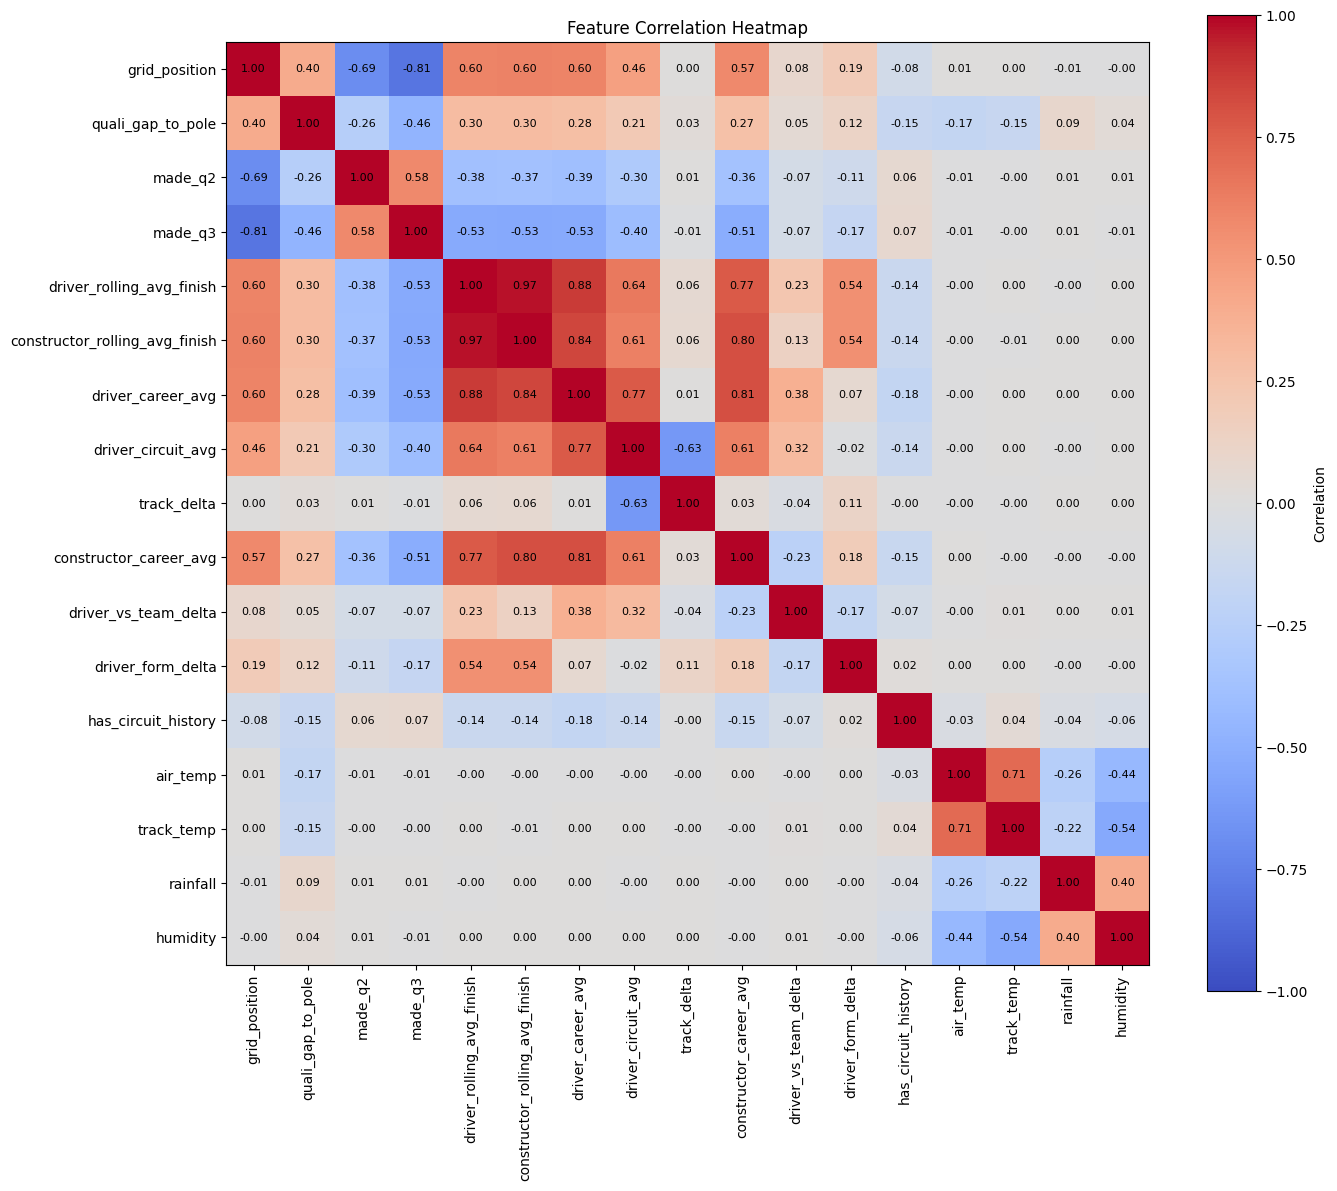

In [32]:
import matplotlib.pyplot as plt
import numpy as np

numeric_features = [
    'grid_position', 'quali_gap_to_pole', 'made_q2', 'made_q3',
    'driver_rolling_avg_finish', 'constructor_rolling_avg_finish',
    'driver_career_avg', 'driver_circuit_avg', 'track_delta',
    'constructor_career_avg', 'driver_vs_team_delta', 'driver_form_delta',
    'has_circuit_history', 'air_temp', 'track_temp', 'rainfall', 'humidity'
]

feature_corr = model_df[numeric_features].corr()

plt.figure(figsize=(14, 12))
plt.imshow(feature_corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xticks(range(len(numeric_features)), numeric_features, rotation=90)
plt.yticks(range(len(numeric_features)), numeric_features)

# Add correlation values as text
for i in range(len(numeric_features)):
    for j in range(len(numeric_features)):
        plt.text(j, i, f'{feature_corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)

plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

In [33]:
feature_corr_spearman = model_df[numeric_features].corr(method='spearman')
print(feature_corr_spearman.round(2))

                                grid_position  quali_gap_to_pole  made_q2  \
grid_position                            1.00               0.76    -0.70   
quali_gap_to_pole                        0.76               1.00    -0.47   
made_q2                                 -0.70              -0.47     1.00   
made_q3                                 -0.81              -0.83     0.58   
driver_rolling_avg_finish                0.59               0.55    -0.38   
constructor_rolling_avg_finish           0.59               0.56    -0.38   
driver_career_avg                        0.59               0.54    -0.39   
driver_circuit_avg                       0.46               0.43    -0.31   
track_delta                             -0.08              -0.08     0.07   
constructor_career_avg                   0.56               0.52    -0.37   
driver_vs_team_delta                     0.14               0.14    -0.11   
driver_form_delta                        0.20               0.19    -0.12   

In [34]:
import xgboost
print(xgboost.__version__)

3.2.0


In [35]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("XGBoost ready")

XGBoost ready


In [36]:
train = model_df[model_df['season'].isin([2023, 2024])].copy()
test = model_df[model_df['season'] == 2025].copy()

print(f"Train: {train.shape}")
print(f"Test: {test.shape}")

Train: (919, 23)
Test: (479, 23)


In [37]:
feature_cols_numeric = [
    'grid_position', 'quali_gap_to_pole', 'made_q2', 'made_q3',
    'driver_rolling_avg_finish', 'constructor_rolling_avg_finish',
    'driver_career_avg', 'driver_circuit_avg', 'track_delta',
    'constructor_career_avg', 'driver_vs_team_delta', 'driver_form_delta',
    'has_circuit_history', 'air_temp', 'track_temp', 'rainfall', 'humidity'
]

# Combine train and test temporarily to ensure consistent one-hot columns
combined = pd.concat([train, test], keys=['train', 'test'])
combined_encoded = pd.get_dummies(combined, columns=['constructor_id', 'circuit_id'], drop_first=True)

train_encoded = combined_encoded.loc['train']
test_encoded = combined_encoded.loc['test']

print(train_encoded.shape)
print(test_encoded.shape)

(919, 56)
(479, 56)


In [38]:
target = 'points_finish'

# Get the final list of all feature columns (numeric + one-hot encoded categoricals)
exclude_cols = ['points_finish', 'season', 'round', 'date', 'driver_id', 'finish_position', 'points', 'status']
final_feature_cols = [col for col in train_encoded.columns if col not in exclude_cols]

X_train = train_encoded[final_feature_cols]
y_train = train_encoded[target]
X_test = test_encoded[final_feature_cols]
y_test = test_encoded[target]

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(919, 52) (919,)
(479, 52) (479,)


In [39]:
baseline_features = ['grid_position']

X_train_baseline = X_train[baseline_features]
X_test_baseline = X_test[baseline_features]

baseline_model = xgb.XGBClassifier(random_state=42)
baseline_model.fit(X_train_baseline, y_train)

baseline_predictions = baseline_model.predict(X_test_baseline)
baseline_accuracy = accuracy_score(y_test, baseline_predictions)

print(f"Baseline accuracy (grid_position only): {baseline_accuracy:.3f}")

Baseline accuracy (grid_position only): 0.766


In [40]:
full_model = xgb.XGBClassifier(random_state=42)
full_model.fit(X_train, y_train)

full_predictions = full_model.predict(X_test)
full_accuracy = accuracy_score(y_test, full_predictions)

print(f"Baseline accuracy (grid_position only): {baseline_accuracy:.3f}")
print(f"Full model accuracy (all features): {full_accuracy:.3f}")

Baseline accuracy (grid_position only): 0.766
Full model accuracy (all features): 0.749


In [41]:
importance = pd.Series(full_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(importance.head(15))

made_q3                      0.627758
circuit_id_Montréal          0.062985
constructor_id_alpine        0.035614
driver_career_avg            0.021105
quali_gap_to_pole            0.020751
constructor_career_avg       0.018729
grid_position                0.015547
rainfall                     0.014909
circuit_id_Melbourne         0.013934
constructor_id_mercedes      0.012295
constructor_id_ferrari       0.012266
made_q2                      0.011618
driver_circuit_avg           0.009908
driver_rolling_avg_finish    0.009875
circuit_id_São Paulo         0.009742
dtype: float32


In [42]:
trimmed_features = [
    'grid_position',       # strongest single original signal
    'made_q3',             # strongest correlation with target overall
    'made_q2',
    'quali_gap_to_pole',
    'driver_rolling_avg_finish',   # keep ONE form metric, not all 5 redundant ones
    'track_delta',          # nearly independent of everything else (good!)
    'driver_vs_team_delta',  # also fairly independent
    'has_circuit_history'
]

X_train_trimmed = X_train[trimmed_features]
X_test_trimmed = X_test[trimmed_features]

trimmed_model = xgb.XGBClassifier(random_state=42)
trimmed_model.fit(X_train_trimmed, y_train)

trimmed_predictions = trimmed_model.predict(X_test_trimmed)
trimmed_accuracy = accuracy_score(y_test, trimmed_predictions)

print(f"Baseline accuracy (grid_position only): {baseline_accuracy:.3f}")
print(f"Full model accuracy (52 features): {full_accuracy:.3f}")
print(f"Trimmed model accuracy (8 features): {trimmed_accuracy:.3f}")

Baseline accuracy (grid_position only): 0.766
Full model accuracy (52 features): 0.749
Trimmed model accuracy (8 features): 0.747


In [43]:
trimmed_importance = pd.Series(trimmed_model.feature_importances_, index=trimmed_features).sort_values(ascending=False)
print(trimmed_importance)

made_q3                      0.910833
made_q2                      0.019331
grid_position                0.017223
driver_rolling_avg_finish    0.015337
quali_gap_to_pole            0.010769
has_circuit_history          0.010275
track_delta                  0.008375
driver_vs_team_delta         0.007857
dtype: float32


In [44]:
single_feature_model = xgb.XGBClassifier(random_state=42)
single_feature_model.fit(X_train[['made_q3']], y_train)
single_pred = single_feature_model.predict(X_test[['made_q3']])
single_accuracy = accuracy_score(y_test, single_pred)

print(f"made_q3 alone: {single_accuracy:.3f}")
print(f"grid_position alone: {baseline_accuracy:.3f}")

made_q3 alone: 0.779
grid_position alone: 0.766


In [45]:
combo_features = ['made_q3', 'grid_position']

combo_model = xgb.XGBClassifier(random_state=42)
combo_model.fit(X_train[combo_features], y_train)
combo_predictions = combo_model.predict(X_test[combo_features])
combo_accuracy = accuracy_score(y_test, combo_predictions)

print(f"made_q3 alone: {single_accuracy:.3f}")
print(f"grid_position alone: {baseline_accuracy:.3f}")
print(f"made_q3 + grid_position: {combo_accuracy:.3f}")

made_q3 alone: 0.779
grid_position alone: 0.766
made_q3 + grid_position: 0.775


In [46]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [2, 3, 4, 5],
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 0.1, 0.3]
}

grid_search = GridSearchCV(
    xgb.XGBClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='accuracy'
)

grid_search.fit(X_train[['made_q3', 'grid_position']], y_train)

print(f"Best params: {grid_search.best_params_}")
print(f"Best CV accuracy: {grid_search.best_score_:.3f}")

tuned_model = grid_search.best_estimator_
tuned_predictions = tuned_model.predict(X_test[['made_q3', 'grid_position']])
tuned_accuracy = accuracy_score(y_test, tuned_predictions)
print(f"Tuned model test accuracy: {tuned_accuracy:.3f}")

Best params: {'learning_rate': 0.3, 'max_depth': 2, 'n_estimators': 200}
Best CV accuracy: 0.791
Tuned model test accuracy: 0.760


In [47]:
pd.read_sql("SELECT season, COUNT(*) as races FROM races GROUP BY season ORDER BY season", engine)

,season,races
0,2022,22
1,2023,22
2,2024,24
3,2025,24


In [48]:
df_check = pd.read_sql("""
SELECT 
    rr.driver_id,
    rr.constructor_id,
    rr.grid_position,
    rr.finish_position,
    rr.points,
    rr.points_finish,
    r.season,
    r.round,
    r.circuit_id,
    r.date,
    q.q1_time,
    q.q2_time,
    q.q3_time,
    w.air_temp,
    w.track_temp,
    w.rainfall,
    w.humidity
FROM race_results rr
JOIN races r ON rr.race_id = r.race_id
LEFT JOIN qualifying_results q ON q.race_id = rr.race_id AND q.driver_id = rr.driver_id
LEFT JOIN weather w ON w.race_id = rr.race_id
WHERE r.season = 2022
ORDER BY r.date, rr.finish_position
""", engine)

print(df_check.shape)

df_check['made_q2'] = df_check['q2_time'].notna().astype(int)
df_check['made_q3'] = df_check['q3_time'].notna().astype(int)

check_cols = ['grid_position', 'made_q2', 'made_q3', 'air_temp', 'track_temp', 'rainfall', 'humidity', 'points_finish']
correlations_2022 = df_check[check_cols].corr()['points_finish'].drop('points_finish').sort_values(ascending=False)
print(correlations_2022)

(440, 17)
made_q3          5.367186e-01
made_q2          3.797605e-01
humidity         1.510388e-16
air_temp         1.027106e-16
rainfall         1.529707e-17
track_temp      -6.291602e-18
grid_position   -4.520638e-01
Name: points_finish, dtype: float64


In [49]:
df_check_all = pd.read_sql("""
SELECT 
    rr.driver_id,
    rr.constructor_id,
    rr.grid_position,
    rr.finish_position,
    rr.points,
    rr.points_finish,
    r.season,
    r.round,
    r.circuit_id,
    r.date,
    q.q1_time,
    q.q2_time,
    q.q3_time,
    w.air_temp,
    w.track_temp,
    w.rainfall,
    w.humidity
FROM race_results rr
JOIN races r ON rr.race_id = r.race_id
LEFT JOIN qualifying_results q ON q.race_id = rr.race_id AND q.driver_id = rr.driver_id
LEFT JOIN weather w ON w.race_id = rr.race_id
ORDER BY r.date, rr.finish_position
""", engine)

print(df_check_all.shape)
print(df_check_all['season'].value_counts().sort_index())

df_check_all['made_q2'] = df_check_all['q2_time'].notna().astype(int)
df_check_all['made_q3'] = df_check_all['q3_time'].notna().astype(int)

check_cols = ['grid_position', 'made_q2', 'made_q3', 'air_temp', 'track_temp', 'rainfall', 'humidity', 'points_finish']
correlations_all = df_check_all[check_cols].corr()['points_finish'].drop('points_finish').sort_values(ascending=False)
print(correlations_all)

(1838, 17)
season
2022    440
2023    440
2024    479
2025    479
Name: count, dtype: int64
made_q3          0.566021
made_q2          0.403039
track_temp       0.000983
air_temp         0.000243
humidity        -0.000269
rainfall        -0.000610
grid_position   -0.556381
Name: points_finish, dtype: float64


In [50]:
pd.read_sql("SELECT season, COUNT(*) as races FROM races GROUP BY season ORDER BY season", engine)

,season,races
0,2022,22
1,2023,22
2,2024,24
3,2025,24


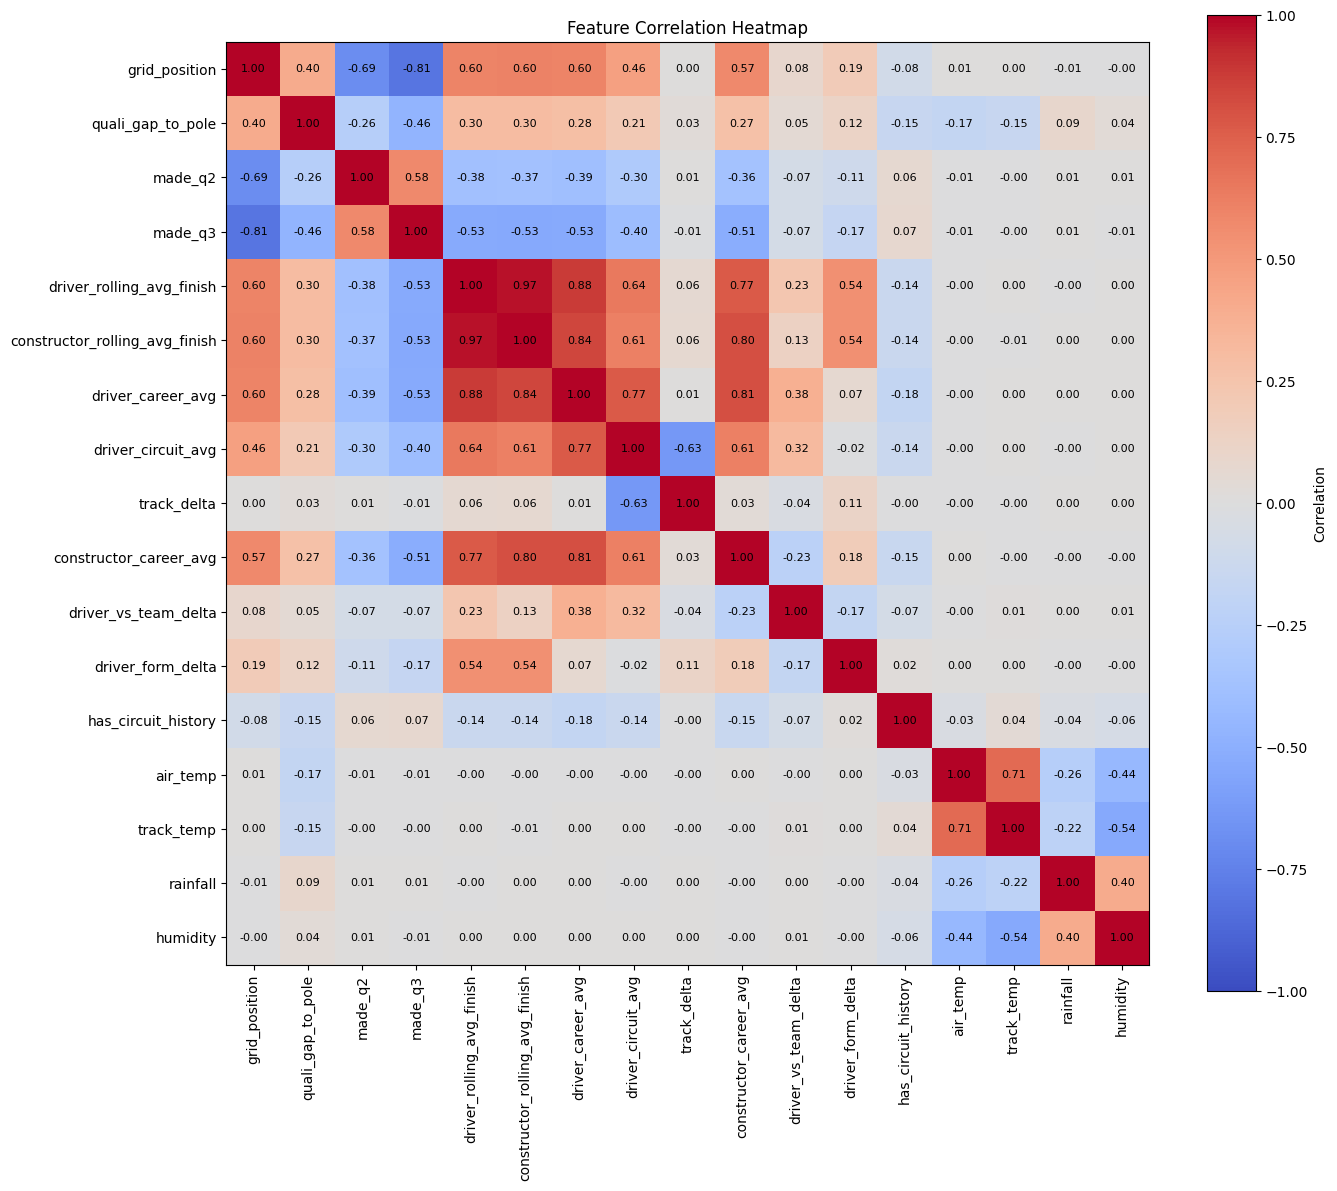

In [51]:
import matplotlib.pyplot as plt
import numpy as np

numeric_features = [
    'grid_position', 'quali_gap_to_pole', 'made_q2', 'made_q3',
    'driver_rolling_avg_finish', 'constructor_rolling_avg_finish',
    'driver_career_avg', 'driver_circuit_avg', 'track_delta',
    'constructor_career_avg', 'driver_vs_team_delta', 'driver_form_delta',
    'has_circuit_history', 'air_temp', 'track_temp', 'rainfall', 'humidity'
]

feature_corr = model_df[numeric_features].corr()

plt.figure(figsize=(14, 12))
plt.imshow(feature_corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xticks(range(len(numeric_features)), numeric_features, rotation=90)
plt.yticks(range(len(numeric_features)), numeric_features)

# Add correlation values as text
for i in range(len(numeric_features)):
    for j in range(len(numeric_features)):
        plt.text(j, i, f'{feature_corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)

plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()